# 🎛️ 03-自适应学习率与 Adam

> 目标：回答三个问题——**为什么逐参数步长**（稀疏特征）、**AdaGrad 为什么后期停摆**、
> **Adam 的偏差校正在干什么**。并手写 Adam 与 `torch.optim.Adam` 逐位对照。

## §1 一刀切学习率的问题

词向量等**稀疏特征**：少数样本才出现，梯度稀有但需要大更新；密集特征需要稳定小步长。
统一 $\eta$ 无法两全 → 思路：**每个参数按自身历史梯度幅度缩放步长**。

## §2 三步演化（背诵主线）

| 优化器 | 统计量 | 更新 | 问题 |
|--------|--------|------|------|
| AdaGrad | $G \gets G + g^2$（累加） | $w \gets w - \frac{\eta}{\sqrt{G}+\epsilon}g$ | $G$ 单调增 → 步长 $\to 0$，后期停摆 |
| RMSProp | $E \gets \beta E + (1-\beta)g^2$（EMA） | $w \gets w - \frac{\eta}{\sqrt{E}+\epsilon}g$ | 无动量，仍用固定 $\eta$ |
| Adam | $m,v$ 双 EMA + 偏差校正 | $w \gets w - \eta \frac{\hat m}{\sqrt{\hat v}+\epsilon}$ | 参数量 ×2 状态 |

**Adam 四条公式**（Kingma & Ba 2015）：

$$m_t = \beta_1 m_{t-1} + (1-\beta_1)g_t \qquad v_t = \beta_2 v_{t-1} + (1-\beta_2)g_t^2$$
$$\hat m_t = \frac{m_t}{1-\beta_1^t} \qquad \hat v_t = \frac{v_t}{1-\beta_2^t} \qquad w \gets w - \eta \frac{\hat m_t}{\sqrt{\hat v_t}+\epsilon}$$

> **为什么校正**：$m_1 = (1-\beta_1)g_1$，被 $1-\beta_1=0.1$ 缩小了 10 倍；除以 $1-\beta_1^t$ 恰好还原「真实 EMA 权重和」。（EMA 权重和为 $\sum_{i=0}^{t-1}\beta^i = (1-\beta^t)/(1-\beta)$，除以它即归一化。）

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# ---------- 手写三类自适应优化器（统一接口 step(w, g, t)） ----------
class AdaGrad:
    def __init__(self, lr=0.1, eps=1e-8):
        self.lr, self.eps = lr, eps
        self.G = None
    def step(self, w, g, t):
        self.G = g * g if self.G is None else self.G + g * g
        return w - self.lr * g / (np.sqrt(self.G) + self.eps)

class RMSProp:
    def __init__(self, lr=0.01, beta=0.9, eps=1e-8):
        self.lr, self.beta, self.eps = lr, beta, eps
        self.E = None
    def step(self, w, g, t):
        self.E = (1 - self.beta) * g * g if self.E is None else self.beta * self.E + (1 - self.beta) * g * g
        return w - self.lr * g / (np.sqrt(self.E) + self.eps)

class Adam:
    def __init__(self, lr=0.01, b1=0.9, b2=0.999, eps=1e-8):
        self.lr, self.b1, self.b2, self.eps = lr, b1, b2, eps
        self.m = self.v = None
    def step(self, w, g, t):
        t1 = t + 1
        self.m = (1 - self.b1) * g if self.m is None else self.b1 * self.m + (1 - self.b1) * g
        self.v = (1 - self.b2) * g * g if self.v is None else self.b2 * self.v + (1 - self.b2) * g * g
        m_hat = self.m / (1 - self.b1**t1)
        v_hat = self.v / (1 - self.b2**t1)
        return w - self.lr * m_hat / (np.sqrt(v_hat) + self.eps)

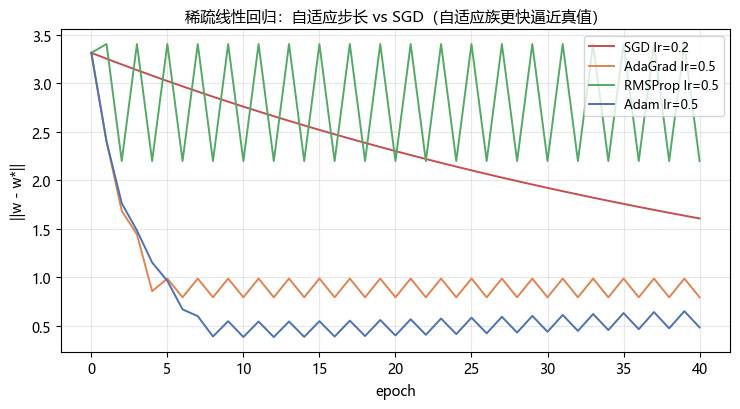

In [2]:
# ---------- 实验 1：稀疏特征场景（10 维，只有 0 号特征常出现） ----------
rng = np.random.default_rng(0)
N, D = 500, 10
X = np.zeros((N, D))
for i in range(N):
    X[i, rng.integers(0, D)] = 1.0          # 每个样本只有一个特征=1（稀疏）
    if i % 10 == 0:
        X[i, 0] = 1.0                        # 0 号特征频繁出现
w_true = rng.normal(size=D)
y = X @ w_true + rng.normal(scale=0.1, size=N)

def train(opt_factory, epochs=40, lr=None):
    w = np.zeros(D); dists = [np.linalg.norm(w - w_true)]
    for e in range(epochs):
        g = X.T @ (X @ w - y) / N
        w = opt_factory(lr=lr).step(w, g, e) if lr else opt_factory().step(w, g, e)
        dists.append(np.linalg.norm(w - w_true))
    return np.array(dists)

fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.plot(train(lambda lr=None: type('S', (), {'step': lambda s, w, g, t: w - 0.2 * g})(), 40),
       label='SGD lr=0.2', color='#C44E52', lw=1.4)
ax.plot(train(lambda lr=0.5: AdaGrad(lr=lr), 40), label='AdaGrad lr=0.5', color='#DD8452', lw=1.4)
ax.plot(train(lambda lr=0.5: RMSProp(lr=lr), 40), label='RMSProp lr=0.5', color='#55A868', lw=1.4)
ax.plot(train(lambda lr=0.5: Adam(lr=lr), 40), label='Adam lr=0.5', color='#4C72B0', lw=1.4)
ax.set_xlabel('epoch'); ax.set_ylabel('||w - w*||')
ax.set_title('稀疏线性回归：自适应步长 vs SGD（自适应族更快逼近真值）', fontsize=11)
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

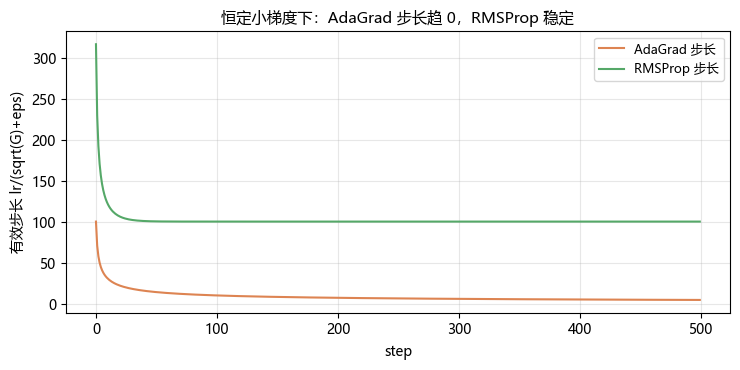

In [3]:
# ---------- 实验 2：AdaGrad 后期停摆演示 ----------
# 固定一个小梯度 g=0.01，看步长如何随时间衰减
steps = 500
G = 0.0; lr = 1.0; eps = 1e-8
steps_adagrad = []
for t in range(steps):
    G += 0.01**2
    steps_adagrad.append(lr / (np.sqrt(G) + eps))
E = 0.0; beta = 0.9
steps_rms = []
for t in range(steps):
    E = beta * E + (1 - beta) * 0.01**2
    steps_rms.append(lr / (np.sqrt(E) + eps))

fig, ax = plt.subplots(figsize=(7.5, 3.8))
ax.plot(steps_adagrad, label='AdaGrad 步长', color='#DD8452', lw=1.5)
ax.plot(steps_rms, label='RMSProp 步长', color='#55A868', lw=1.5)
ax.set_xlabel('step'); ax.set_ylabel('有效步长 lr/(sqrt(G)+eps)')
ax.set_title('恒定小梯度下：AdaGrad 步长趋 0，RMSProp 稳定', fontsize=11)
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [4]:
# ---------- 实验 3：手写 Adam vs torch.optim.Adam 逐位对照 ----------
import torch

torch.manual_seed(1)
w_torch = torch.randn(5, 3, dtype=torch.float64, requires_grad=True)
w_np = w_torch.detach().numpy().copy()

opt_t = torch.optim.Adam([w_torch], lr=0.01, betas=(0.9, 0.999), eps=1e-8)
adam = Adam(lr=0.01, b1=0.9, b2=0.999, eps=1e-8)

maxdiff = 0.0
for t in range(20):
    # 相同的随机梯度
    g = torch.randn(5, 3, dtype=torch.float64)
    loss = (w_torch * g).sum()
    opt_t.zero_grad(); loss.backward()
    opt_t.step()
    # 手写版用同样梯度
    w_np = adam.step(w_np, g.numpy(), t)
    diff = np.abs(w_np - w_torch.detach().numpy()).max()
    maxdiff = max(maxdiff, diff)
print(f'手写 Adam vs torch.optim.Adam 最大误差: {maxdiff:.2e}')
assert maxdiff < 1e-12, '对照失败'
print('对照通过：完全一致')

手写 Adam vs torch.optim.Adam 最大误差: 1.11e-16
对照通过：完全一致


## §3 超参与工程建议（必背）

| 优化器 | 默认 lr | 关键超参 | 适用 |
|--------|--------|----------|------|
| AdaGrad | 0.01 | — | 稀疏特征（词向量） |
| RMSProp | 0.001 | $\beta=0.9$ | RNN（Hinton 原版） |
| Adam | 0.001 | $\beta_1=0.9,\ \beta_2=0.999$ | 默认首选（NLP/RL/生成） |

- **ε 的位置**：$1/(\sqrt{v}+\epsilon)$，不是 $1/\sqrt{v+\epsilon}$（数值性质不同）
- **Adam 与权重衰减耦合**：L2 正则被自适应步长干扰 → AdamW（04 篇）
- **CV 上 Adam 常输给 SGD+Momentum**：平坦极小值假说（Adam 收敛到尖锐极小，泛化差）

## §4 常见 bug 与边界

- **偏差校正遗漏**：忘除以 $1-\beta^t$，头几百步更新量异常小
- **状态共享**：m/v 必须按参数张量独立维护
- **首步 None**：`m=None` 时直接取 $g$（等价于 EMA 从 0 开始）
- **lr 忘调度**：Adam 不调度一般也能用，但配上 warmup+decay 更好（05 篇）

## §5 面试追问与扩展

1. **Adam vs SGD 最终精度**：Adam 快、稳；SGD+Momentum+调度在部分 CV 任务泛化更好
2. **为什么 RNN 用 RMSProp/Adam**：RNN 梯度跨步尺度剧变，逐元素缩放能稳住
3. **偏差校正的另一种等价解释**：把 EMA 归一化（除以权重和）
4. **Adam 在 LLM 中的表现**：锁死 AdamW + 特殊调度（见 04/05/07 篇）

## §6 自测清单

- [ ] 默写 AdaGrad / RMSProp / Adam 公式
- [ ] 默写 Adam 偏差校正并解释为什么
- [ ] 手写 Adam 与 torch 对照（本文已断言）
- [ ] 解释 AdaGrad 后期停摆、RMSProp 如何修复
- [ ] 说清默认超参（lr/β₁/β₂/ε）

> 💡 下节预告：AdamW 解耦权重衰减与 LAMB / Lion（04 篇）。